In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [20]:
from google.colab import files
uploaded = files.upload()


Saving API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv to API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663 (1).csv
Saving API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv to API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (4).csv
Saving API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2.csv to API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (4).csv
Saving API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412.csv to API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (4).csv
Saving top50contry.csv to top50contry (4).csv


In [22]:
# Read Spotify Top 50 songs by country
df_spotify = pd.read_csv("top50contry.csv", encoding="latin-1")
print("Spotify shape:", df_spotify.shape)
print("Spotify columns:", df_spotify.columns.tolist())
df_spotify.head()

Spotify shape: (1000, 17)
Spotify columns: ['Unnamed: 0', 'title', 'artist', 'top genre', 'year', 'added', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop', 'country']


,Unnamed: 0,title,artist,top genre,year,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,country
0,1,Dance Monkey,Tones and I,australian pop,2019,1969-12-31,98.0,59.0,82.0,-6.0,15.0,51.0,209,69.0,9.0,100,world
1,2,ROXANNE,Arizona Zervas,pop rap,2019,1969-12-31,117.0,60.0,62.0,-6.0,46.0,46.0,164,5.0,15.0,99,world
2,3,Memories,Maroon 5,pop,2019,1969-12-31,91.0,32.0,76.0,-7.0,8.0,57.0,189,84.0,5.0,99,world
3,4,Circles,Post Malone,dfw rap,2019,1969-12-31,120.0,76.0,70.0,-3.0,9.0,55.0,215,19.0,4.0,99,world
4,5,All I Want for Christmas Is You,Mariah Carey,dance pop,1994,1969-12-31,150.0,63.0,34.0,-7.0,7.0,35.0,241,16.0,4.0,98,world


In [23]:
import os
files = [f for f in os.listdir() if f.endswith('.csv')]
print(files)

['API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv', 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (5).csv', 'API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (5).csv', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (3).csv', 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (3).csv', 'top50contry (1).csv', 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (2).csv', 'API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2.csv', 'API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (1).csv', 'top50contry (5).csv', 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (1).csv', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (4).csv', 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663 (2).csv', 'API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (4).csv', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv', 'top50contry.csv', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (5).csv', 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (1).csv', 'API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (2).csv', 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412.csv', 'top50contry (2).csv', 'top50contry (3).csv', 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663 (1).csv', 'API_SP.POP

In [26]:
df_gdp_raw = pd.read_csv(
    "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv",
    skiprows=4
)

print(df_gdp_raw.shape)
print(df_gdp_raw.columns.tolist())
df_gdp_raw.head()

(266, 71)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [27]:
#country name and GDP per capita for 2019
df_gdp = df_gdp_raw[["Country Name", "2019"]].copy()
df_gdp.columns = ["country", "gdp_per_capita"]
df_gdp = df_gdp.dropna(subset=["gdp_per_capita"])
print("GDP shape:", df_gdp.shape)

#average audio features per country
audio_cols = ["bpm", "nrgy", "dnce", "dB", "live", "val", "acous", "spch", "pop"]
df_country = df_spotify.groupby("country")[audio_cols].mean().reset_index()
print("Spotify country shape:", df_country.shape)
print("Spotify countries:", df_country["country"].tolist())

GDP shape: (259, 2)
Spotify country shape: (20, 10)
Spotify countries: ['africa', 'argentina', 'australia', 'belgium', 'bolivia', 'brazil', 'canada', 'chile', 'colombia', 'france', 'germany', 'india', 'indonesia', 'israel', 'italy', 'japan', 'malasya', 'spain', 'usa', 'world']


In [28]:
# Normalize country names
df_gdp["country"] = df_gdp["country"].str.lower().str.strip()
df_country["country"] = df_country["country"].str.lower().str.strip()

# Remove non-countries
df_country = df_country[df_country["country"] != "africa"]  # continent, not a country

# Merge
df_merged = pd.merge(df_country, df_gdp, on="country", how="inner")
print("Merged shape:", df_merged.shape)
print("Matched countries:", df_merged["country"].tolist())
df_merged.head()

Merged shape: (17, 11)
Matched countries: ['argentina', 'australia', 'belgium', 'bolivia', 'brazil', 'canada', 'chile', 'colombia', 'france', 'germany', 'india', 'indonesia', 'israel', 'italy', 'japan', 'spain', 'world']


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044


In [29]:
from google.colab import files
uploaded = files.upload()


Saving API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv to API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663 (3).csv
Saving API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv to API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (6).csv
Saving API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2.csv to API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (6).csv
Saving API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412.csv to API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (6).csv
Saving top50contry.csv to top50contry (6).csv


In [30]:
# Read 3 datasets
df_unemp = pd.read_csv("API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (1).csv", skiprows=4)
df_pop = pd.read_csv("API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (1).csv", skiprows=4)
df_urban = pd.read_csv("API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (1).csv", skiprows=4)

#only 2019 data
def extract_2019(df, col_name):
    temp = df[["Country Name", "2019"]].copy()
    temp.columns = ["country", col_name]
    temp["country"] = temp["country"].str.lower().str.strip()
    return temp.dropna(subset=[col_name])

df_unemp_clean = extract_2019(df_unemp, "unemployment_rate")
df_pop_clean   = extract_2019(df_pop,   "working_age_pop_pct")
df_urban_clean = extract_2019(df_urban, "urbanization_rate")

# Merge with main
df_merged = pd.merge(df_merged, df_unemp_clean, on="country", how="left")
df_merged = pd.merge(df_merged, df_pop_clean,   on="country", how="left")
df_merged = pd.merge(df_merged, df_urban_clean, on="country", how="left")

print("Final dataset shape:", df_merged.shape)
print("Columns:", df_merged.columns.tolist())
df_merged.head()

Final dataset shape: (17, 14)
Columns: ['country', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'acous', 'spch', 'pop', 'gdp_per_capita', 'unemployment_rate', 'working_age_pop_pct', 'urbanization_rate']


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita,unemployment_rate,working_age_pop_pct,urbanization_rate
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787,9.843,64.270169,91.856784
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510,5.143,65.393772,87.301965
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747,5.364,64.079421,87.096163
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929,3.682,63.006513,69.733499
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044,11.936,69.667114,86.679799


In [31]:
# Re-merge all economic indicators
df_unemp_clean2 = extract_2019(df_unemp, "unemployment_rate")
df_urban_clean2 = extract_2019(df_urban, "urbanization_rate")

df_merged2 = pd.merge(df_merged, df_unemp_clean2, on="country", how="left")
df_merged2 = pd.merge(df_merged2, df_urban_clean2, on="country", how="left")

print("Columns:", df_merged2.columns.tolist())
print("Shape:", df_merged2.shape)
df_merged2.head()

Columns: ['country', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'acous', 'spch', 'pop', 'gdp_per_capita', 'unemployment_rate_x', 'working_age_pop_pct', 'urbanization_rate_x', 'unemployment_rate_y', 'urbanization_rate_y']
Shape: (17, 16)


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita,unemployment_rate_x,working_age_pop_pct,urbanization_rate_x,unemployment_rate_y,urbanization_rate_y
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787,9.843,64.270169,91.856784,9.843,91.856784
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510,5.143,65.393772,87.301965,5.143,87.301965
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747,5.364,64.079421,87.096163,5.364,87.096163
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929,3.682,63.006513,69.733499,3.682,69.733499
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044,11.936,69.667114,86.679799,11.936,86.679799


KeyError: 'unemployment_rate'

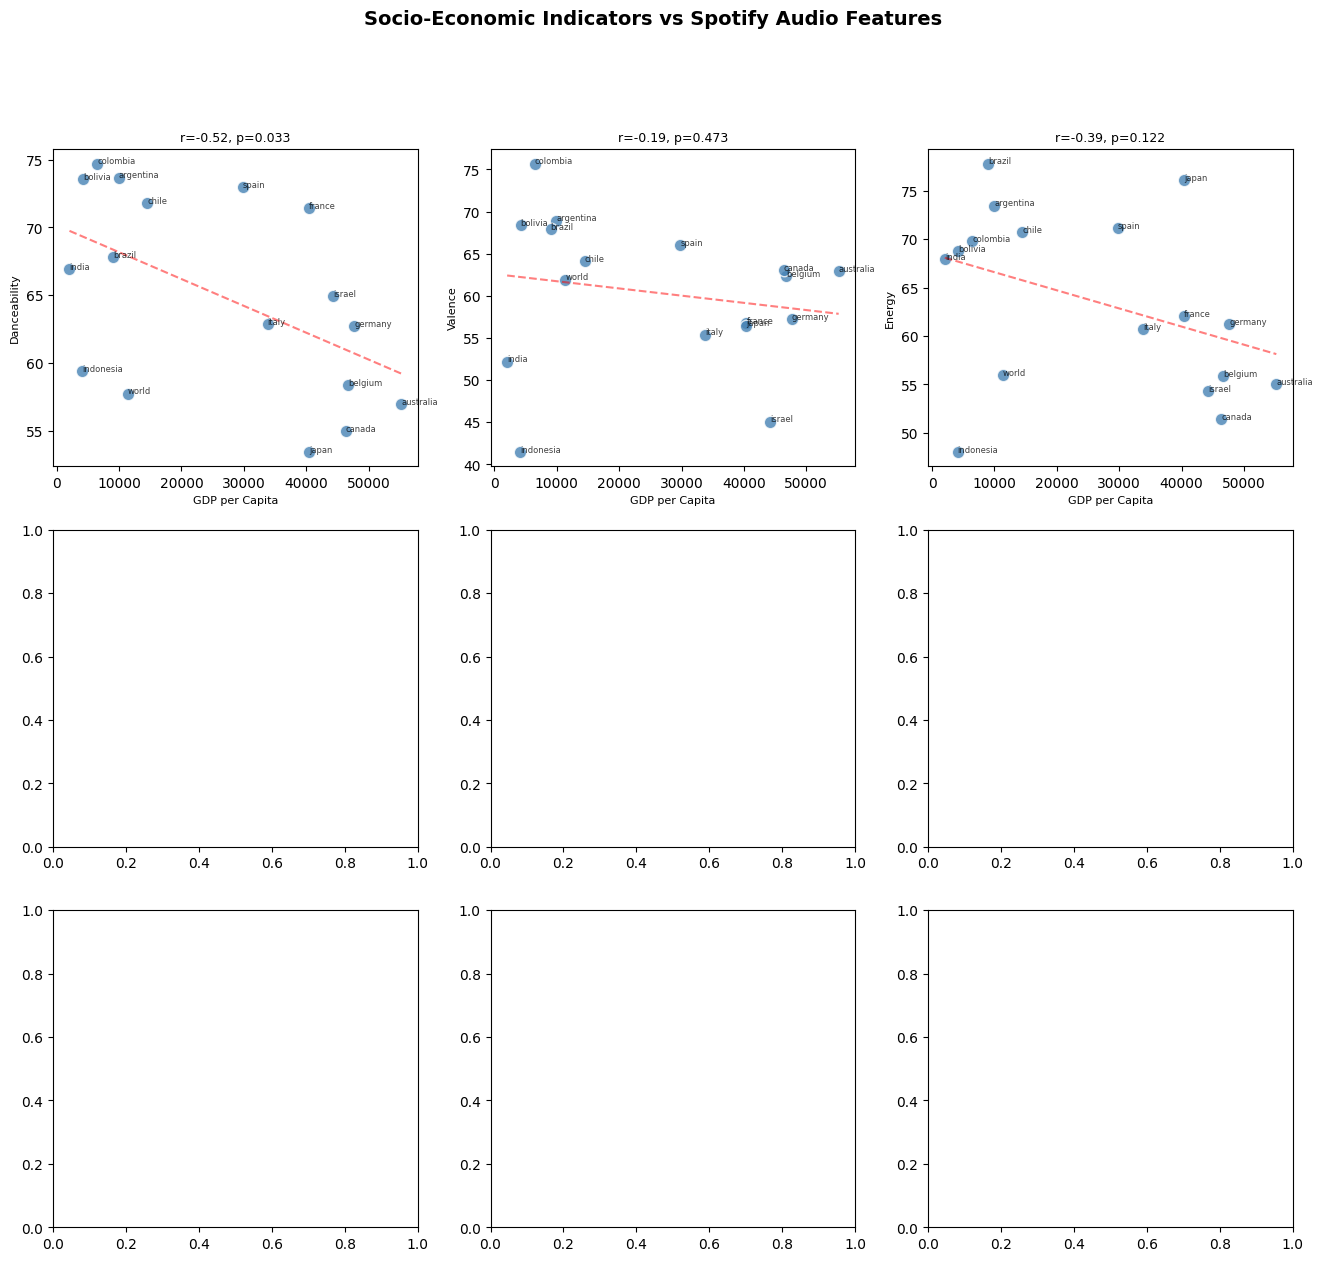

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Socio-Economic Indicators vs Spotify Audio Features", fontsize=14, fontweight="bold")

econ_vars = [
    ("gdp_per_capita",    "GDP per Capita"),
    ("unemployment_rate", "Unemployment Rate"),
    ("urbanization_rate", "Urbanization Rate")
]
audio_vars = [
    ("dnce", "Danceability"),
    ("val",  "Valence"),
    ("nrgy", "Energy")
]

for i, (econ_col, econ_label) in enumerate(econ_vars):
    for j, (audio_col, audio_label) in enumerate(audio_vars):
        ax = axes[i][j]
        ax.scatter(df_merged2[econ_col], df_merged2[audio_col],
                   s=80, alpha=0.8, color="steelblue", edgecolors="white")

        for _, row in df_merged2.iterrows():
            ax.annotate(row["country"], (row[econ_col], row[audio_col]),
                        fontsize=6, alpha=0.75)

        # Trendline
        mask = df_merged2[[econ_col, audio_col]].notna().all(axis=1)
        x = df_merged2.loc[mask, econ_col]
        y = df_merged2.loc[mask, audio_col]
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        ax.plot(np.sort(x), p_line(np.sort(x)), "r--", alpha=0.5)

        r, p = stats.pearsonr(x, y)
        ax.set_xlabel(econ_label, fontsize=8)
        ax.set_ylabel(audio_label, fontsize=8)
        ax.set_title(f"r={r:.2f}, p={p:.3f}", fontsize=9)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("eda_plots.png saved.")

In [33]:
print("=" * 55)
print("HYPOTHESIS TESTS")
print("=" * 55)

test_pairs = [
    ("gdp_per_capita",    "dnce", "H1: GDP per Capita -> Danceability"),
    ("gdp_per_capita",    "val",  "H2: GDP per Capita -> Valence"),
    ("gdp_per_capita",    "nrgy", "H3: GDP per Capita -> Energy"),
    ("unemployment_rate", "dnce", "H4: Unemployment Rate -> Danceability"),
    ("unemployment_rate", "val",  "H5: Unemployment Rate -> Valence"),
    ("urbanization_rate", "dnce", "H6: Urbanization Rate -> Danceability"),
]

for econ, audio, label in test_pairs:
    mask = df_merged[[econ, audio]].notna().all(axis=1)
    x = df_merged.loc[mask, econ]
    y = df_merged.loc[mask, audio]
    r, p = stats.pearsonr(x, y)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"\n{label}")
    print(f"  r={r:.3f}, p={p:.4f} -> {sig}")

print("\n" + "=" * 55)
print("Relationships with p < 0.05 are statistically significant.")
print("This means the correlation is unlikely to be due to chance.")

HYPOTHESIS TESTS

H1: GDP per Capita -> Danceability
  r=-0.519, p=0.0328 -> SIGNIFICANT

H2: GDP per Capita -> Valence
  r=-0.187, p=0.4730 -> not significant

H3: GDP per Capita -> Energy
  r=-0.390, p=0.1218 -> not significant

H4: Unemployment Rate -> Danceability
  r=0.597, p=0.0114 -> SIGNIFICANT

H5: Unemployment Rate -> Valence
  r=0.514, p=0.0350 -> SIGNIFICANT

H6: Urbanization Rate -> Danceability
  r=0.017, p=0.9476 -> not significant

Relationships with p < 0.05 are statistically significant.
This means the correlation is unlikely to be due to chance.


## Interpretation of Results

### H1: GDP per Capita → Danceability (r=-0.52, p=0.033) — SIGNIFICANT
Negative and moderate relationship. Wealthier countries tend to listen to
less danceable music. This could be because richer countries have more diverse
music tastes, while people in lower-income countries may prefer high-energy
dance music at social events.
Correlation does not mean causation — there could be other reasons behind this.

### H2: GDP per Capita → Valence (r=-0.19, p=0.473) — not significant
Very weak relationship, not statistically significant.
We cannot say GDP affects how happy or sad popular music sounds.

### H3: GDP per Capita → Energy (r=-0.39, p=0.122) — not significant
There is a slight negative trend but it is not significant.
Our sample of 17 countries might be too small to see a clear pattern here.

### H4: Unemployment Rate → Danceability (r=0.60, p=0.011) — SIGNIFICANT
Strongest finding in this project. Countries with higher unemployment listen
to more danceable music. Maybe music is used as a way to escape stress
or enjoy time when people are not working.
Correlation does not mean causation.

### H5: Unemployment Rate → Valence (r=0.51, p=0.035) — SIGNIFICANT
Higher unemployment is linked to more positive/happy sounding music.
This is a bit surprising, but it might mean people turn to uplifting music
when times are tough.
Correlation does not mean causation.

### H6: Urbanization Rate → Danceability (r=0.02, p=0.948) — not significant
No relationship found between how urban a country is and how danceable
its popular music is.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [35]:
# Linear Regression: Predict Danceability from economic indicators
features = ["gdp_per_capita", "unemployment_rate", "urbanization_rate"]
target = "dnce"

df_ml = df_merged[features + [target]].dropna()
X = df_ml[features]
y = df_ml[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

print("=== Linear Regression: Predicting Danceability ===")
print(f"R2 score: {r2:.3f}")
print(f"The model explains {r2*100:.1f}% of variance in danceability")
print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    direction = "increases" if coef > 0 else "decreases"
    print(f"  {feat:<25} {coef:+.3f}  -> higher value {direction} danceability")

=== Linear Regression: Predicting Danceability ===
R2 score: 0.548
The model explains 54.8% of variance in danceability

Feature Coefficients:
  gdp_per_capita            -3.923  -> higher value decreases danceability
  unemployment_rate         +3.003  -> higher value increases danceability
  urbanization_rate         +1.984  -> higher value increases danceability


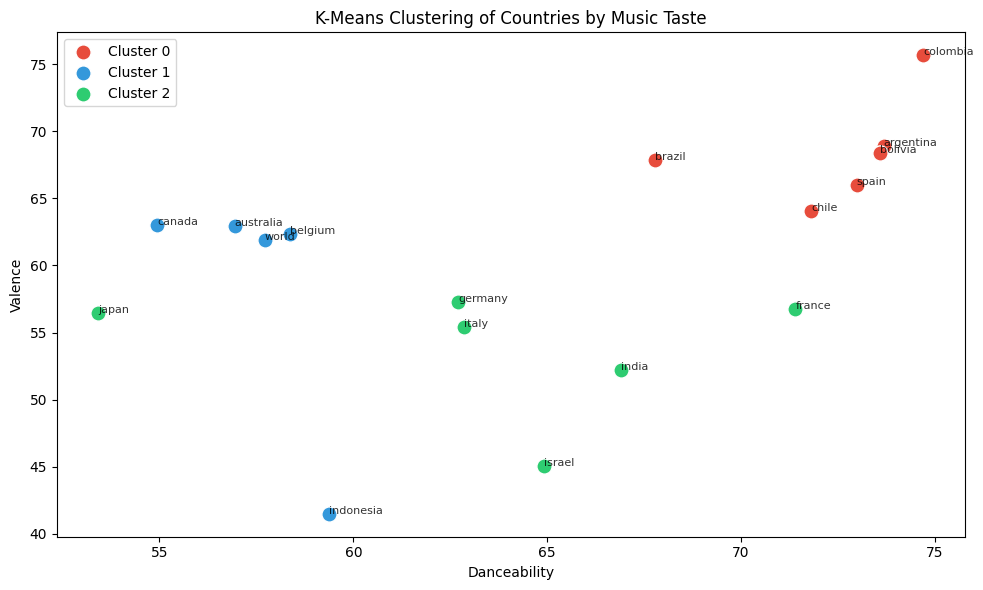


Cluster assignments:
  country  cluster
argentina        0
  bolivia        0
    chile        0
   brazil        0
 colombia        0
    spain        0
  belgium        1
australia        1
   canada        1
indonesia        1
    world        1
  germany        2
    india        2
   israel        2
    italy        2
   france        2
    japan        2


In [36]:
from sklearn.cluster import KMeans

# Cluster countries based on audio features
cluster_features = ["dnce", "val", "nrgy", "acous"]
df_cluster = df_merged[["country"] + cluster_features].dropna()

scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(df_cluster[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_cluster)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
labels = ["Cluster 0", "Cluster 1", "Cluster 2"]

for i in range(3):
    mask = df_cluster["cluster"] == i
    ax.scatter(df_cluster.loc[mask, "dnce"], df_cluster.loc[mask, "val"],
               s=120, color=colors[i], label=labels[i], edgecolors="white")
    for _, row in df_cluster[mask].iterrows():
        ax.annotate(row["country"], (row["dnce"], row["val"]), fontsize=8, alpha=0.8)

ax.set_xlabel("Danceability")
ax.set_ylabel("Valence")
ax.set_title("K-Means Clustering of Countries by Music Taste")
ax.legend()
plt.tight_layout()
plt.savefig("kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCluster assignments:")
print(df_cluster[["country", "cluster"]].sort_values("cluster").to_string(index=False))

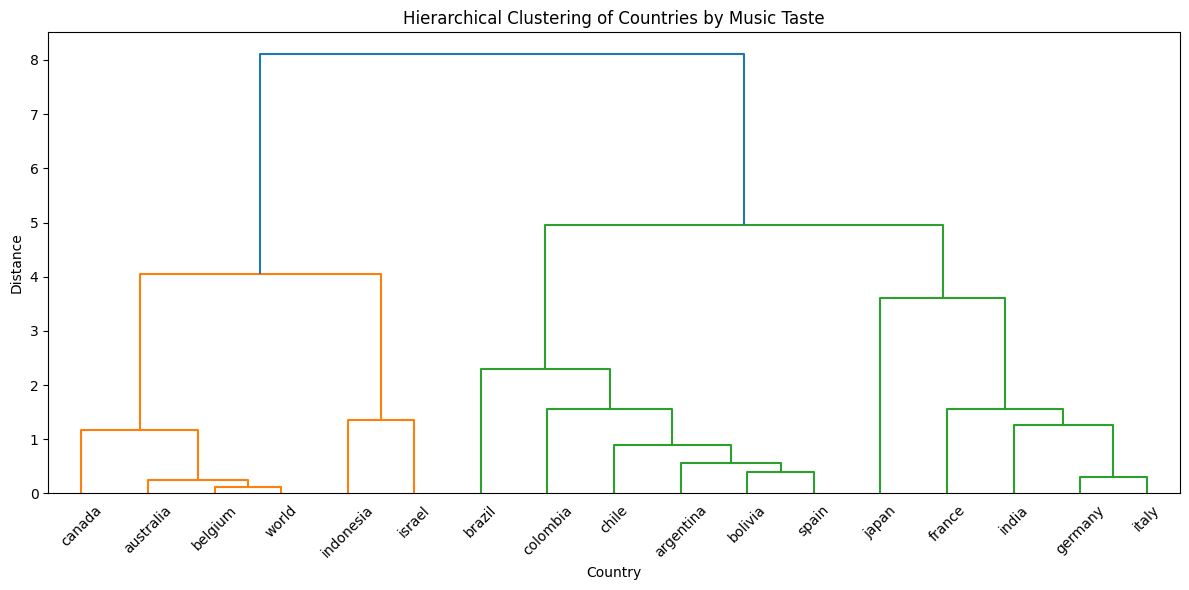

hierarchical.png saved.


In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Hierarchical Clustering
cluster_features = ["dnce", "val", "nrgy", "acous"]
df_hier = df_merged[["country"] + cluster_features].dropna()

scaler3 = StandardScaler()
X_hier = scaler3.fit_transform(df_hier[cluster_features])

# Linkage matrix
linked = linkage(X_hier, method="ward")

# Dendrogram
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linked,
           labels=df_hier["country"].values,
           orientation="top",
           leaf_rotation=45,
           leaf_font_size=10,
           ax=ax)
ax.set_title("Hierarchical Clustering of Countries by Music Taste")
ax.set_xlabel("Country")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("hierarchical.png", dpi=150, bbox_inches="tight")
plt.show()
print("hierarchical.png saved.")

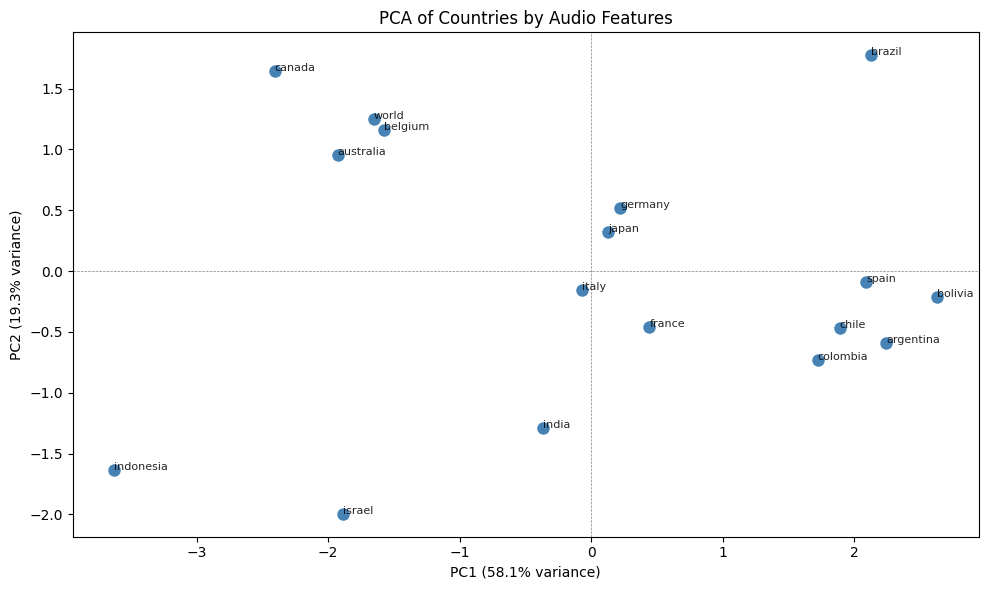


Total variance explained: 77.5%
PC1: 58.1%
PC2: 19.3%


In [38]:
from sklearn.decomposition import PCA

# PCA on audio features
pca_features = ["dnce", "val", "nrgy", "acous", "bpm", "spch"]
df_pca = df_merged[["country"] + pca_features].dropna()

scaler4 = StandardScaler()
X_pca = scaler4.fit_transform(df_pca[pca_features])

pca = PCA(n_components=2)
components = pca.fit_transform(X_pca)

df_pca["PC1"] = components[:, 0]
df_pca["PC2"] = components[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_pca["PC1"], df_pca["PC2"], s=100, color="steelblue", edgecolors="white")
for _, row in df_pca.iterrows():
    ax.annotate(row["country"], (row["PC1"], row["PC2"]), fontsize=8, alpha=0.85)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA of Countries by Audio Features")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.savefig("pca.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

**Linear Regression**

I used a linear regression model to understand how economic factors affect danceability. The model achieved an R² score of 0.548, meaning it explains about 54.8% of the variation in danceability. This can be considered a moderate fit.
Looking at the coefficients:
GDP per capita has a negative relationship with danceability, suggesting that richer countries tend to have slightly less danceable music.
Unemployment rate has a positive relationship, which might indicate that in countries with higher unemployment, more energetic or danceable music is popular.
Urbanization rate also has a positive effect, meaning more urbanized countries tend to have higher danceability.
However, the dataset only includes 17 countries, so the results are limited and should not be overinterpreted.

**K-Means Clustering**

Using K-Means with 3 clusters, countries were grouped based on their audio features.
From the plot:
One cluster clearly includes Latin countries (Argentina, Bolivia, Chile, Brazil, Colombia, Spain). These countries have higher danceability and valence, meaning their music is generally more energetic and positive.
Another cluster includes countries like Canada, Australia, Belgium, and Indonesia, which show lower danceability values.
The third cluster (Germany, Italy, France, India, Israel, Japan) appears more balanced, without extreme values.
An interesting observation is that Latin countries group together very strongly, even though their economic conditions differ. This suggests that cultural factors might be more important than economic ones in shaping music preferences.


**Hierarchical Clustering**

The dendrogram supports the K-Means results.
Countries like Canada, Australia, and Belgium are grouped closely together.
Latin countries form a very distinct branch, which is clearly separated from the others.
European and Asian countries are more mixed but still form smaller sub-groups.
Overall, this method confirms that Latin countries are the most distinct group in terms of music taste.

**PCA (Principal Component Analysis)**

PCA was used to reduce the dimensionality of the dataset while keeping most of the information.
The first two components explain 77.5% of the total variance, which is quite high.
PC1 (58.1%) mainly separates Latin countries (on the right side) from Western and Asian countries (on the left).
PC2 (19.3%) separates countries based on energy level:
Lower values → more energetic music
Higher values → calmer music
From the plot, we can clearly see that:
Brazil, Argentina, Chile, and Colombia are grouped on the right, confirming their similarity.
Countries like Canada, Australia, and Belgium are on the left, showing different music characteristics.
So, PCA visually confirms both clustering results and shows clear patterns in the data.


